# Audit COMPAS for racial bias using IBM AIF360

# Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [7]:
from aif360.datasets import CompasDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [10]:
# 1) Load dataset
data = CompasDataset()

In [12]:
# import os
# import urllib.request
#
# # Target directory
# target_dir = r"E:\Python3.13\Lib\site-packages\aif360\data\raw\compas"
# os.makedirs(target_dir, exist_ok=True)
#
# # File path
# file_path = os.path.join(target_dir, "compas-scores-two-years.csv")
#
# # Download from GitHub
# url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
# urllib.request.urlretrieve(url, file_path)
#
# print("Dataset downloaded successfully!")

In [13]:
# Protected attribute: race (privileged = Caucasian)
privileged_groups = [{'race': 1}]      # 1=Caucasian in AIF360 encoding
unprivileged_groups = [{'race': 0}]    # 0=Non-Caucasian


# 2) Train/test split


In [15]:

X = pd.DataFrame(data.features, columns=data.feature_names)
y = pd.Series(data.labels.ravel(), name='two_year_recid')
A = pd.Series(data.protected_attributes[:, data.protected_attribute_names.index('race')], name='race')

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.3, random_state=42, stratify=y
)

# 3) Baseline classifier


In [17]:
clf = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


# Wrap into AIF360 BinaryLabelDataset

In [20]:
from aif360.datasets import BinaryLabelDataset

# Combine into one DataFrame
df_test = pd.concat([X_test, y_test, A_test], axis=1)[X_test.columns.tolist() + ['two_year_recid','race']]
# Create BinaryLabelDataset
test_bld = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=df_test,
    label_names=['two_year_recid'],
    protected_attribute_names=['race'],
    instance_weights_name=None
)

# Copy and attach predictions
test_bld_pred = test_bld.copy()
test_bld_pred.labels = y_pred.reshape(-1, 1)

# 4) Metrics: disparate impact, FPR/FNR disparities


In [22]:
bm = BinaryLabelDatasetMetric(test_bld,
                              privileged_groups=privileged_groups,
                              unprivileged_groups=unprivileged_groups)
di = bm.disparate_impact()

cm = ClassificationMetric(test_bld, test_bld_pred,
                          privileged_groups=privileged_groups,
                          unprivileged_groups=unprivileged_groups)
fpr_priv = cm.false_positive_rate(privileged=True)
fpr_unpriv = cm.false_positive_rate(privileged=False)
fpr_diff = fpr_unpriv - fpr_priv

fnr_priv = cm.false_negative_rate(privileged=True)
fnr_unpriv = cm.false_negative_rate(privileged=False)
fnr_diff = fnr_unpriv - fnr_priv

In [23]:
print(f"Disparate Impact (unpriv/priv): {di:.3f}")
print(f"FPR — unprivileged: {fpr_unpriv:.3f}, privileged: {fpr_priv:.3f}, diff: {fpr_diff:.3f}")
print(f"FNR — unprivileged: {fnr_unpriv:.3f}, privileged: {fnr_priv:.3f}, diff: {fnr_diff:.3f}")

Disparate Impact (unpriv/priv): 1.303
FPR — unprivileged: 0.282, privileged: 0.204, diff: 0.078
FNR — unprivileged: 0.396, privileged: 0.588, diff: -0.191


# 5) Visualization: FPR/FNR by race group

In [25]:
metrics_df = pd.DataFrame({
    'Group': ['Unprivileged', 'Privileged'],
    'FPR': [fpr_unpriv, fpr_priv],
    'FNR': [fnr_unpriv, fnr_priv]
}).melt(id_vars='Group', var_name='Metric', value_name='Rate')

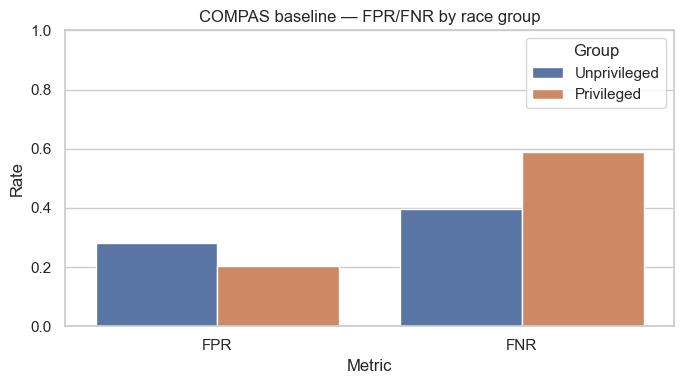

In [26]:
sns.set(style='whitegrid')
plt.figure(figsize=(7,4))
sns.barplot(data=metrics_df, x='Metric', y='Rate', hue='Group')
plt.title('COMPAS baseline — FPR/FNR by race group')
plt.ylim(0, 1)
plt.legend(title='Group')
plt.tight_layout()
plt.show()

# 6) Remediation: Reweighing preprocessor and re-train


In [29]:
from aif360.datasets import BinaryLabelDataset

# Combine into one DataFrame and explicitly select columns
df_train = pd.concat([X_train, y_train, A_train], axis=1)
df_train = df_train[X_train.columns.tolist() + ['two_year_recid', 'race']]

# Construct BinaryLabelDataset
train_bld = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=df_train,
    label_names=['two_year_recid'],
    protected_attribute_names=['race']
)

In [30]:
rw = Reweighing(privileged_groups=privileged_groups, unprivileged_groups=unprivileged_groups)
train_bld_rw = rw.fit_transform(train_bld)

# Train with instance weights


In [32]:
clf_rw = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(max_iter=1000))
])
clf_rw.fit(train_bld_rw.features, train_bld_rw.labels.ravel())


,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,False
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


# Evaluate post-remediation


In [34]:
y_pred_rw = clf_rw.predict(test_bld.features)
test_bld_pred_rw = test_bld.copy()
test_bld_pred_rw.labels = y_pred_rw.reshape(-1, 1)

cm_rw = ClassificationMetric(test_bld, test_bld_pred_rw,
                             privileged_groups=privileged_groups,
                             unprivileged_groups=unprivileged_groups)
fpr_diff_rw = cm_rw.false_positive_rate(privileged=False) - cm_rw.false_positive_rate(privileged=True)
fnr_diff_rw = cm_rw.false_negative_rate(privileged=False) - cm_rw.false_negative_rate(privileged=True)
di_rw = BinaryLabelDatasetMetric(test_bld,
                                 privileged_groups=privileged_groups,
                                 unprivileged_groups=unprivileged_groups).disparate_impact()


In [35]:
print(f"[After Reweighing] DI: {di_rw:.3f}, FPR diff: {fpr_diff_rw:.3f}, FNR diff: {fnr_diff_rw:.3f}")

[After Reweighing] DI: 1.303, FPR diff: 0.078, FNR diff: -0.191
